In [1]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# File path
file_path = '20250318_speed.txt'

# Read the data into a DataFrame
df = pd.read_csv(file_path)

# Convert 'time' column to datetime format
df['time'] = pd.to_datetime(df['time'], format='%y-%m-%d %H:%M:%S')

# Set 'time' column as the index
df.set_index('time', inplace=True)

# Localize the naive datetime to UTC first  
df.index = df.index.tz_localize('UTC').tz_convert('America/Los_Angeles')

# Ensure that longitude values are negative
df['lon'] = -df['lon']

df.tail()
# print(df['lat'].tail())s
# print(df['lon'].tail())

# Function to convert DD.MMmm to decimal degrees
# From ChatGPT
def convert_to_decimal_degrees(coord):
    degrees = int(coord)  # Extract degrees (integer part)
    minutes = abs(coord - degrees) * 100  # Extract the minutes
    decimal_degrees = abs(degrees) + minutes / 60  # Convert minutes to decimal and add to degrees
    return decimal_degrees if coord >= 0 else -decimal_degrees  # Keep the sign for negative coordinates

# Apply the conversion function to the lat and lon columns
df['lat_decimal'] = df['lat'].apply(convert_to_decimal_degrees)
df['lon_decimal'] = df['lon'].apply(convert_to_decimal_degrees)

print(df[['lat_decimal', 'lon_decimal']])

                           lat_decimal  lon_decimal
time                                               
2025-03-18 09:00:58-07:00    37.972333  -122.534833
2025-03-18 09:01:09-07:00    37.972333  -122.534833
2025-03-18 09:01:20-07:00    37.972333  -122.534833
2025-03-18 09:01:32-07:00    37.972167  -122.534833
2025-03-18 09:01:43-07:00    37.972000  -122.534833
...                                ...          ...
2025-03-18 09:31:05-07:00    37.968167  -122.530333
2025-03-18 09:31:16-07:00    37.968000  -122.530667
2025-03-18 09:31:27-07:00    37.968167  -122.530833
2025-03-18 09:31:38-07:00    37.968167  -122.530833
2025-03-18 09:31:50-07:00    37.968167  -122.530833

[167 rows x 2 columns]


In [3]:
# Create a Folium map centered at the first location
m = folium.Map(location=[df.iloc[0]['lat_decimal'], df.iloc[0]['lon_decimal']], zoom_start=16)

# Prepare the coordinates for the polyline
coordinates = df[['lat_decimal', 'lon_decimal']].values.tolist()

# Add a line connecting the points
folium.PolyLine(coordinates, color='blue', weight=2.5, opacity=1).add_to(m)

# Save map to an HTML file
m.save('20250318_speed.html')


In [4]:
df.keys()

Index(['tempC', 'tempF', 'humidity', 'pressurehPa', 'fix', 'fixQual', 'lat',
       'latDir', 'lon', 'lonDir', 'speed', 'angle', 'alt', 'satNum', 'vBat',
       'lat_decimal', 'lon_decimal'],
      dtype='object')

In [5]:
print('Power-On Duration')
duration = df.index[-1]-df.index[0]
print(duration)

Power-On Duration
0 days 00:30:52


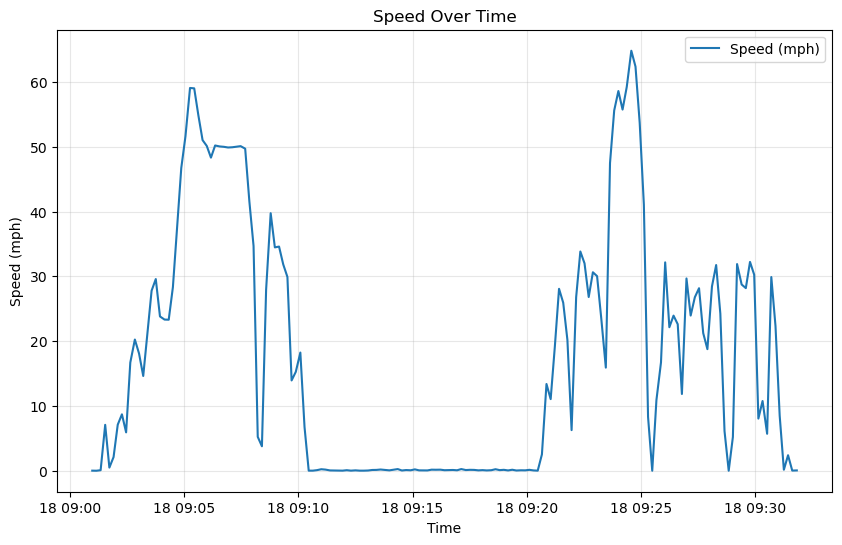

In [ ]:
import matplotlib.pyplot as plt

# Convert m/s to mph
df['speed_mph'] = df['speed'] * 1.15  # 1 m/s = 2.23694 mph

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['speed_mph'], label='Speed (mph)')
plt.xlabel('Time')
plt.ylabel('Speed (mph)')
plt.title('Speed Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()